# Classifier Training Pipeline (AlphaEarth Embeddings)

Trains an MLP classifier on AlphaEarth expert-embedding features using manually added positive and negative samples. The notebook matches labels to embeddings, balances the classes, builds a spatially aware train/test split, sweeps classification thresholds, and saves the final model with its artifacts.

## 1. Imports

In [1]:
# Standard library.
from pathlib import Path
import json
import pickle

# Geospatial and numerical stack.
import geopandas as gpd
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# Modeling and evaluation utilities.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.base import clone as sk_clone
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score

## 2. Paths and Inputs

Set the working directory and point to the embedding and label files used throughout the notebook.

In [2]:
# Root project directory.
WORKING_DIR = Path('/Users/muhammadabdul/Desktop/work/climate_trace/germany_consolidated')

# Input data directories and files.
DATA_DIR = WORKING_DIR / "data" 

EDS_EMBEDDINGS_PATH = DATA_DIR / "embeddings" /"tar_embeddings.gpkg"   # AlphaEarth embedding points.
NEG_LABELS_RAND_PATH = DATA_DIR / "embeddings" /"neg_rand_embeddings.gpkg"    # Random negative embeddings.

POS_LABELS_PATH = DATA_DIR  /"labels" / 'pos' / "pos_labels_tar.gpkg"  # Positive ground-truth labels.
NEG_LABELS_PATH = DATA_DIR /"labels" / 'neg' / "neg_labels_tar.gpkg"    # Non-random negative labels.

## 3. Load Base Data

Load embedding points and the three label sets: positives, non-random negatives, and random negatives.

In [3]:
# Load embeddings and original labeled training points.
embeddings_gdf = gpd.read_file(EDS_EMBEDDINGS_PATH)
embeddings_gdf['geometry'] = embeddings_gdf['geometry'].centroid

pos_labels_gdf = gpd.read_file(POS_LABELS_PATH)
pos_labels_gdf['target'] = 1
pos_labels_gdf['typ'] = 'pos'

neg_labels_gdf = gpd.read_file(NEG_LABELS_PATH)
neg_labels_gdf['target'] = 0
neg_labels_gdf['typ'] = 'neg_nrnd'

neg_labels_rand_gdf = gpd.read_file(NEG_LABELS_RAND_PATH)
neg_labels_rand_gdf['target'] = 0
neg_labels_rand_gdf['typ'] = 'neg_rnd'

/var/folders/6w/y2p0qv_n60x3l94nc3zh2r440000gn/T/ipykernel_75600/4042648739.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  embeddings_gdf['geometry'] = embeddings_gdf['geometry'].centroid


## 4. Match Labels to Embeddings

Project all geometries to meters and use nearest-neighbor matching to attach each label to its closest embedding row.

In [4]:
def match_labels_to_embeddings(labels_gdf):
    # Keep a copy of labels before matching so label metadata can be recovered later.
    labels_tmp = labels_gdf.copy()

    # Project both datasets to EPSG:25832 (ETRS89 / UTM zone 32N) so
    # nearest-neighbor distances are in meters.
    emb_proj = embeddings_gdf.to_crs(25832)
    lbl_proj = labels_tmp.to_crs(25832)

    # Fit nearest-neighbor search on the projected embedding coordinates.
    emb_xy = np.column_stack([emb_proj.geometry.x.values, emb_proj.geometry.y.values])
    nn = NearestNeighbors(n_neighbors=1, algorithm="auto")
    nn.fit(emb_xy)

    # Build label-to-embedding assignments: each label matches to its single
    # nearest embedding (k=1).
    rows = []

    for _, row in lbl_proj.iterrows():
        y_val = int(row["target"])
        k = 1
        dists, inds = nn.kneighbors(
            np.array([[row.geometry.x, row.geometry.y]]),
            n_neighbors=min(k, len(emb_proj)),
        )
        # Record one assignment row per matched embedding.
        for d, emb_i in zip(dists.ravel(), inds.ravel()):
            rows.append(
                {
                    "target": y_val,
                    "emb_idx": int(emb_i),
                    "distance_m": float(d),
                }
            )

    assignments = pd.DataFrame(rows)

    # Pull the matched embedding rows and attach the label metadata.
    matched_gdf = embeddings_gdf.loc[assignments["emb_idx"].values].copy()
    matched_gdf = matched_gdf.reset_index(drop=True)
    matched_gdf["target"] = assignments["target"].values

    # Drop duplicate embeddings (rows with identical feature vectors), keeping
    # the first occurrence so the same embedding region is not sampled twice.
    emd_col = [col for col in matched_gdf.columns if col.startswith('e')]
    matched_gdf = (
        matched_gdf.drop_duplicates(subset=emd_col, keep="first")
    )
    return matched_gdf

In [5]:
# Match positives and non-random negatives to embeddings, then stack them.
pos_matched_gdf = match_labels_to_embeddings(pos_labels_gdf)
neg_matched_gdf = match_labels_to_embeddings(neg_labels_gdf)

all_gdf = pd.concat([pos_matched_gdf, neg_matched_gdf], axis=0)

### 4.1 Balance Classes (1:5 Positive to Negative)

Keep all matched negatives and top up with random negatives so the overall positive-to-negative ratio is 1:5.

In [6]:
# Split matched embeddings by class.
pos_gdf = all_gdf[all_gdf["target"] == 1].copy()
neg_gdf = all_gdf[all_gdf["target"] == 0].copy()

In [7]:
# Target negative count for a 1:5 positive-to-negative ratio.
sample_from_neg = pos_gdf.shape[0] * 5

In [8]:
# Sample the shortfall from the random-negative pool (if any is needed).
sample_from_neg_rand = int(sample_from_neg - neg_gdf.shape[0])
if sample_from_neg_rand > 0:
    neg_gdf_sampled = neg_labels_rand_gdf.sample(n=sample_from_neg_rand, random_state=42)
else:
    neg_gdf_sampled = gpd.GeoDataFrame(columns=neg_labels_rand_gdf.columns)

In [9]:
# Recombine positives with the final negative sample.
if neg_gdf_sampled.shape[0] > 0:
    all_gdf = pd.concat([pos_gdf, neg_gdf, neg_gdf_sampled], ignore_index=True)
else:
    pass

## 5. Feature Columns and Spatially Aware Train/Test Split

Keep numeric feature columns, exclude non-feature fields, and split the data so that nearby points always stay in the same partition.

In [10]:
# Exclude target and geometry from the predictor set.
exclude_cols = {'target', 'geometry', 'id', 'parent_id','typ'}

# Keep only numeric predictors.
feature_cols = [
    col for col in all_gdf.columns
    if col not in exclude_cols and pd.api.types.is_numeric_dtype(all_gdf[col])
]

In [11]:
# Group points into spatial clusters so that any two points within 500 m of each
# other share the same point_id. This keeps nearby samples in the same
# train/test partition below (transitively: A-B and B-C within 500 m => one id).
match_crs = 25832
cluster_radius_m = 500

pos_gdf = all_gdf[all_gdf["target"] == 1].copy()
neg_gdf = all_gdf[all_gdf["target"] == 0].copy()

def get_point_ids(gdf, crs, radius_m):
    coords = np.column_stack(
        (
            gdf.to_crs(crs).geometry.x.values,
            gdf.to_crs(crs).geometry.y.values,
        )
    )
    point_ids = DBSCAN(
        eps=radius_m,
        min_samples=1,
        metric='euclidean',
    ).fit_predict(coords).astype(int)
    return point_ids

# min_samples=1 makes every point a core point, so DBSCAN reduces to
# single-linkage clustering at the 500 m radius (no noise label of -1).
pos_gdf['point_id'] = get_point_ids(pos_gdf, match_crs, cluster_radius_m)
neg_gdf['point_id'] = get_point_ids(neg_gdf, match_crs, cluster_radius_m)

all_gdf = pd.concat([pos_gdf, neg_gdf], ignore_index=True)

### 5.1 Group-Wise Split by Point ID

In [12]:
# Split positive samples by point_id so matched embeddings from the same
# positive label stay in the same partition (60/40 train/test).
pos_gdf = all_gdf[all_gdf["target"] == 1].copy()
unique_groups = list(pos_gdf['point_id'].unique())
train_groups, test_groups = train_test_split(
    unique_groups,
    test_size=0.4,
    random_state=42,
    shuffle=True,
    )

pos_train = pos_gdf[pos_gdf['point_id'].isin(train_groups)]
pos_test = pos_gdf[pos_gdf['point_id'].isin(test_groups)]

In [13]:
# Split negative samples by point_id so matched embeddings from the same
# negative label stay in the same partition (60/40 train/test).
neg_gdf = all_gdf[all_gdf["target"] == 0].copy()
unique_groups = list(neg_gdf['point_id'].unique())
train_groups, test_groups = train_test_split(
    unique_groups,
    test_size=0.4,
    random_state=42,
    shuffle=True,
    )

neg_train = neg_gdf[neg_gdf['point_id'].isin(train_groups)]
neg_test = neg_gdf[neg_gdf['point_id'].isin(test_groups)]

In [14]:
# Combine positive and negative rows into the train/test datasets.
train_gdf = pd.concat([pos_train, neg_train], ignore_index=True)
test_gdf = pd.concat([pos_test, neg_test], ignore_index=True)

In [15]:
# Build model matrices.
X_train = train_gdf[feature_cols]
y_train = train_gdf['target']
X_test = test_gdf[feature_cols]
y_test = test_gdf['target']

## 6. Train Classifier

Fit a scikit-learn pipeline (standard scaling + MLP classifier) on the selected feature columns.

In [ ]:
# Define the classifier pipeline.
model = Pipeline(
    steps=[
        ("scaler", StandardScaler(with_std=False)),
        ("mlp", MLPClassifier(
            random_state=42,
            early_stopping=True,
        )),
    ]
)

# Fit the classifier on the training set.
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('mlp', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",False
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`

## 7. Evaluate Performance and Pick the Threshold with the Highest F1 Score

Sweep classification thresholds, compute train/test metrics, and plot F1, precision, and recall against the threshold.

In [17]:
def get_metrics(model, X_train, y_train, X_test, y_test, threshold=0.5):
    """Compute F1, precision, recall, and accuracy at a given threshold.

    Test-set metrics are returned; train-set metrics are computed alongside
    so overfitting can be checked when needed.
    """
    # Predicted probabilities for the positive class, thresholded to binary predictions.
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    # Test-set metrics.
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # Training-set metrics for comparison.
    y_prob_train = model.predict_proba(X_train)[:, 1]
    y_pred_train = (y_prob_train >= threshold).astype(int)
    accuracy_train = accuracy_score(y_train, y_pred_train)
    precision_train = precision_score(y_train, y_pred_train, zero_division=0)
    recall_train = recall_score(y_train, y_pred_train, zero_division=0)
    f1_train = f1_score(y_train, y_pred_train, zero_division=0)

    return f1, precision, recall, accuracy

Threshold with highest F1 score: 0.45


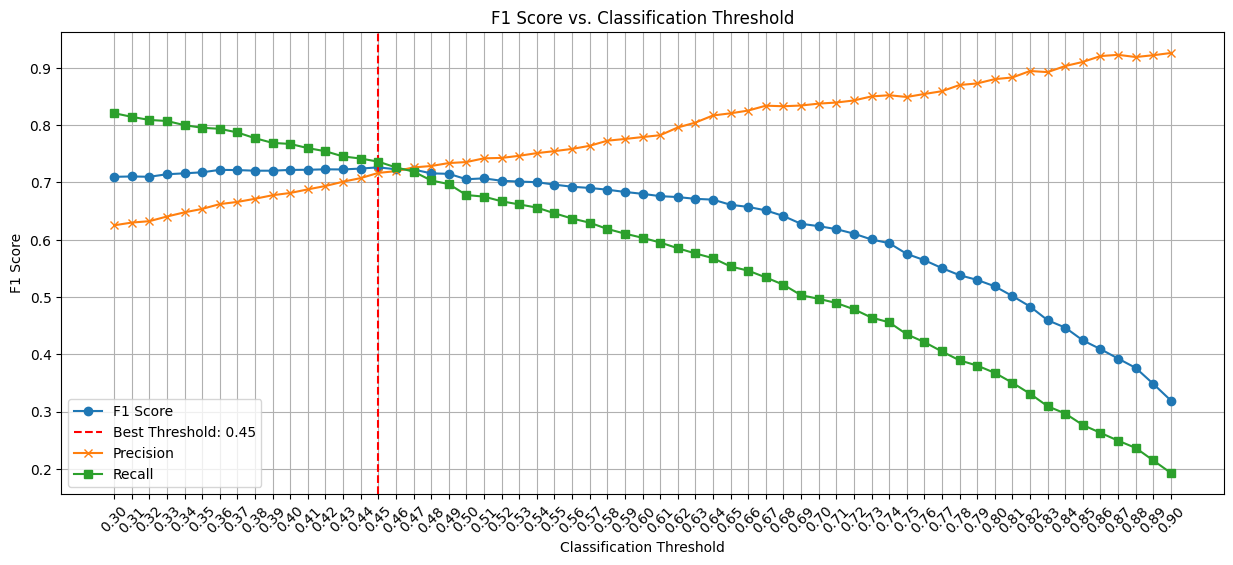

In [18]:
# Sweep thresholds from 0.30 to 0.89 in steps of 0.01 and record metrics.
f1_scores = {}
precision_scores = {}
recall_scores = {}

for threshold in np.arange(0.3, 0.9, 0.01):
    threshold = round(threshold, 2)
    f1, precision, recall, accuracy = get_metrics(model, X_train, y_train, X_test, y_test, threshold=threshold)
    f1_scores[threshold] = f1
    precision_scores[threshold] = precision
    recall_scores[threshold] = recall

# Report the threshold that maximizes F1 on the test set.
print("Threshold with highest F1 score:", max(f1_scores, key=f1_scores.get))

# Plot F1, precision, and recall against the threshold, marking the best F1.
plt.figure(figsize=(15, 6))

plt.plot(list(f1_scores.keys()), list(f1_scores.values()), marker='o', label='F1 Score')
plt.axvline(x=max(f1_scores, key=f1_scores.get), color='red', linestyle='--', label=f'Best Threshold: {max(f1_scores, key=f1_scores.get)}')
plt.plot(list(precision_scores.keys()), list(precision_scores.values()), marker='x', label='Precision')
plt.plot(list(recall_scores.keys()), list(recall_scores.values()), marker='s', label='Recall')
plt.legend()

plt.title('F1 Score vs. Classification Threshold')
plt.xlabel('Classification Threshold')
plt.ylabel('F1 Score')
plt.xticks(np.arange(0.3, 0.9, 0.01), rotation=45)
plt.grid()
plt.show()

In [19]:
# Average Precision on the held-out test set (threshold-independent).
average_precision = average_precision_score(y_test, model.predict_proba(X_test)[:, 1])
print('Average Precision:', average_precision)

Average Precision: 0.7849699060851932


## 8. Train Final Model and Save Artifacts

Retrain the model on all labeled rows, then save the model and its evaluation metrics.

In [20]:
# Clone the evaluated pipeline as the final model object.
final_model = sk_clone(model)

# Train the final model on the entire labeled dataset.
final_model.fit(all_gdf[feature_cols], all_gdf['target'])

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('mlp', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",False
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`

In [21]:
# Create the model output directory.
model_dir = WORKING_DIR / f"model/"
model_dir.mkdir(parents=True, exist_ok=True)

# Save the final model.
model_path = model_dir / f"model.pkl"
with open(model_path, "wb") as f:
    pickle.dump(final_model, f)

# Evaluate the train/test model on the held-out test set at the chosen
# threshold (selected from the sweep above).
threshold = 0.45
training_metrics = get_metrics(model, X_train, y_train, X_test, y_test, threshold=threshold)

# Build the evaluation summary.
metrics = {
    "train_size": int(len(X_train)),
    "test_size": int(len(X_test)),
    "f1_score": training_metrics[0],
    "precision": training_metrics[1],
    "recall": training_metrics[2],
    "accuracy": training_metrics[3],
    "threshold": threshold,
}

# Save metrics to a JSON file.
metrics_path = model_dir / f"metrics.json"
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

### 8.1 Save Training Predictions

Predict on all labeled rows, tag each with its train/test split assignment, and write to GeoJSON for inspection in QGIS.

In [22]:
# Record which geometries belong to the train and test sets.
train_ids = set(train_gdf['geometry'])
test_ids = set(test_gdf['geometry'])

# Keep identifier, target, and geometry columns (plus polygon_id if present).
base_cols = ['point_id', 'target', 'geometry']
optional_cols = ['polygon_id']
selected_cols = [c for c in optional_cols + base_cols if c in all_gdf.columns]

# Predict on all rows and tag each row with its split assignment.
output = all_gdf[selected_cols].copy()
y_prob = model.predict_proba(all_gdf[feature_cols])[:, 1]
y_pred = (y_prob >= threshold).astype(int)
output['predicted'] = y_pred

output['split'] = np.where(
    output['geometry'].isin(train_ids),
    'train',
    np.where(output['geometry'].isin(test_ids), 'test', 'unknown')
)

# Order the output columns.
final_cols = [c for c in ['polygon_id', 'point_id', 'split', 'predicted', 'target', 'geometry'] if c in output.columns]
output = output[final_cols]

# Save predictions to disk.
output_path = model_dir / f'training_predictions.geojson'
output.to_file(output_path, driver='GeoJSON')